# Lab 5 Water Quality Analysis

This notebook currently implements the airborne workflow plus the Sentinel-2
acquisition phase of the Lab 5 pipeline. It loads one ENVI scene, resolves the
nearest hyperspectral bands for the required water-quality products, builds
false-color composites, and prepares the closest Sentinel-2 acquisition for the
same footprint.


In [9]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

if (Path.cwd() / "src").exists():
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.lab5.envi_utils import (
    build_invalid_band_mask,
    find_nearest_band,
    get_ignore_value,
    get_rgb_bands,
    load_envi_image,
    parse_wavelengths,
    read_rgb,
)
from src.lab5.indices import (
    band_by_wavelength,
    chlorophyll_red_edge_peak,
    composite_by_wavelengths,
    doc_proxy_green_red,
    ndci,
    ndti,
    stretch_composite,
)
from src.lab5.sentinel2 import (
    SENTINEL2_REQUIRED_BANDS,
    describe_item,
    download_band,
    load_local_stack,
    open_catalog,
    scene_bbox_wgs84_from_envi,
    scene_grid_from_envi,
    search_s2_items,
    select_best_item,
)

SCENE_PATH = REPO_ROOT / "data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr"
SENTINEL2_DIR = REPO_ROOT / "data/sentinel2"
TARGET_DATE = "2025-06-17"
S2_DAY_WINDOW = 5
S2_CLOUD_LIMIT = 20.0

SCENE_PATH


PosixPath('/Users/ernest.molczan/PycharmProjects/eolabs-clone/lab_5/data/images/221000_Odra_HS_Blok_A_008_VS_join_atm.hdr')

## Scene Summary

The first step is to open the hyperspectral scene, read the wavelength metadata,
mark invalid bands, and resolve the nearest usable airborne bands for the products
planned in the Lab 5 execution plan.


In [10]:
img = load_envi_image(SCENE_PATH)
meta = img.metadata
wavelengths = parse_wavelengths(meta)
ignore_value = get_ignore_value(meta)
invalid_mask = build_invalid_band_mask(meta)
rgb_default = read_rgb(img, get_rgb_bands(meta), ignore_value)

def resolve_target(target_nm: float) -> tuple[int, float]:
    band_index = find_nearest_band(wavelengths, target_nm, invalid_mask)
    return band_index, float(wavelengths[band_index])

target_lookup = {
    target_nm: resolve_target(target_nm)
    for target_nm in (490, 560, 665, 705, 740, 842, 1610)
}

metadata_summary = pd.DataFrame([
    {
        "scene_id": SCENE_PATH.stem,
        "rows": img.nrows,
        "cols": img.ncols,
        "bands": img.nbands,
        "ignore_value": ignore_value,
        "invalid_band_count": int(invalid_mask.sum()) if invalid_mask is not None else 0,
        "wavelength_count": int(len(wavelengths)) if wavelengths is not None else 0,
    }
])

band_summary = pd.DataFrame(
    [
        {
            "target_nm": target_nm,
            "band_index": band_index,
            "actual_wavelength_nm": actual_wavelength,
        }
        for target_nm, (band_index, actual_wavelength) in sorted(target_lookup.items())
    ]
)

display(metadata_summary)
display(band_summary)


,scene_id,rows,cols,bands,ignore_value,invalid_band_count,wavelength_count
0,221000_Odra_HS_Blok_A_008_VS_join_atm,4300,2001,456,15000.0,155,456


,target_nm,band_index,actual_wavelength_nm
0,490,24,490.85
1,560,46,561.17
2,665,78,663.46
3,705,85,685.84
4,740,102,740.18
5,842,134,842.47
6,1610,292,1612.08


## Natural And False-Color Composites

The natural RGB comes from the ENVI `default bands` metadata. The false-color
composites below follow the Lab 5 execution plan:

- vegetation composite: `842 / 665 / 560`
- moisture composite: `1610 / 842 / 665`
- water-focused composite: `705 / 560 / 490`


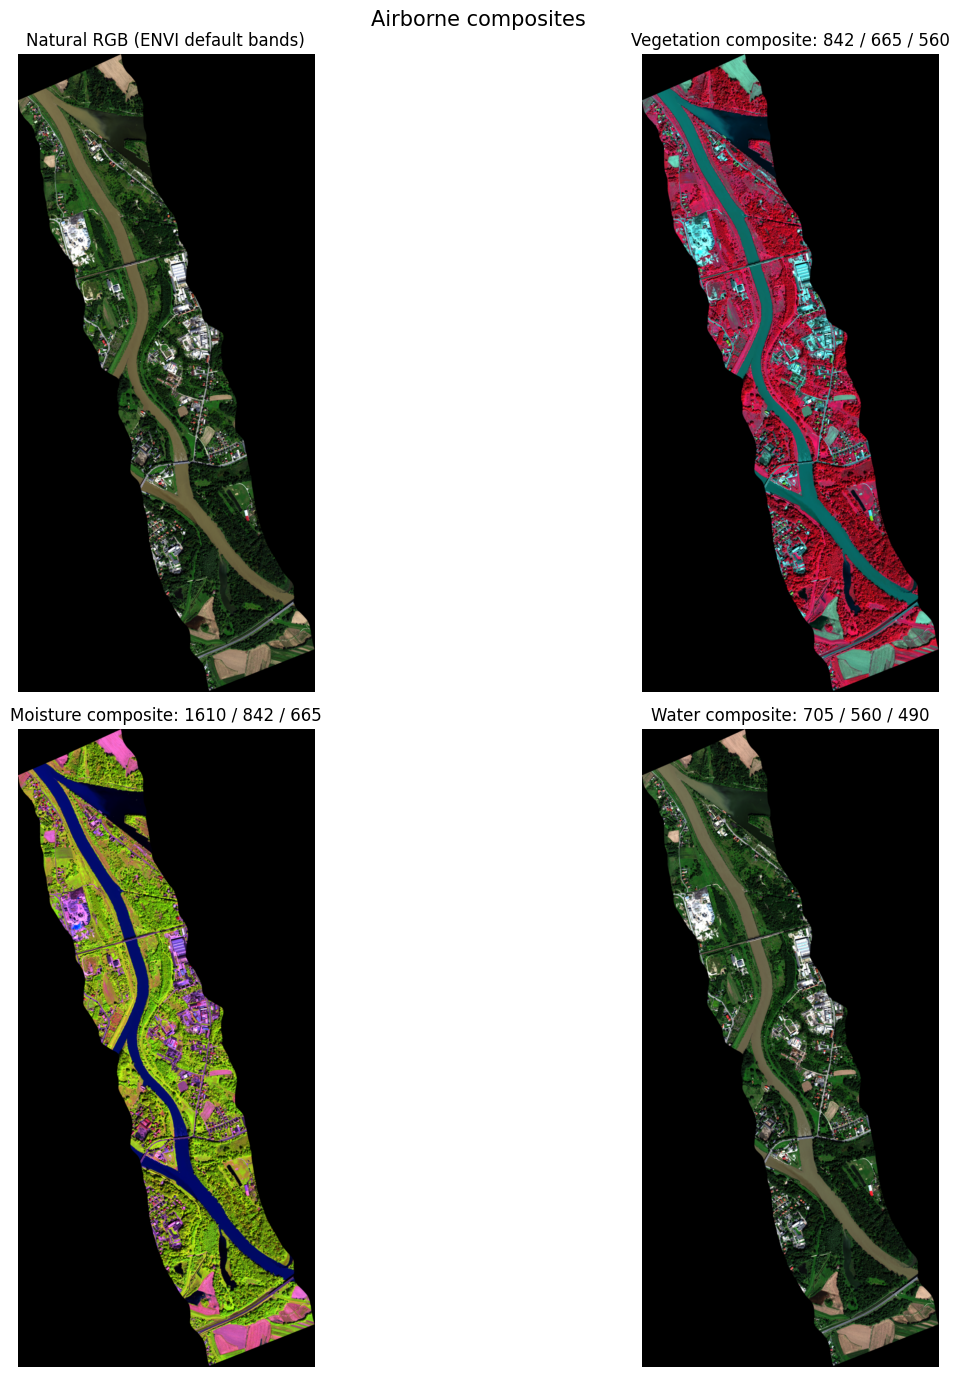

In [11]:
vegetation_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (842, 665, 560),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)
moisture_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (1610, 842, 665),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)
water_rgb = stretch_composite(
    composite_by_wavelengths(
        img,
        wavelengths,
        (705, 560, 490),
        invalid_mask=invalid_mask,
        ignore_value=ignore_value,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(16, 14), subplot_kw={"aspect": "auto"})
fig.suptitle("Airborne composites", fontsize=15)

axes[0, 0].imshow(rgb_default, interpolation="bilinear")
axes[0, 0].set_title("Natural RGB (ENVI default bands)")
axes[0, 0].axis("off")

axes[0, 1].imshow(vegetation_rgb, interpolation="bilinear")
axes[0, 1].set_title("Vegetation composite: 842 / 665 / 560")
axes[0, 1].axis("off")

axes[1, 0].imshow(moisture_rgb, interpolation="bilinear")
axes[1, 0].set_title("Moisture composite: 1610 / 842 / 665")
axes[1, 0].axis("off")

axes[1, 1].imshow(water_rgb, interpolation="bilinear")
axes[1, 1].set_title("Water composite: 705 / 560 / 490")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Airborne Water-Quality Index Maps

This section computes the airborne-only Lab 5 products implemented in
`src/lab5/indices.py`:

- `chl_red_edge_peak`
- `ndci`
- `doc_proxy`
- `ndti`


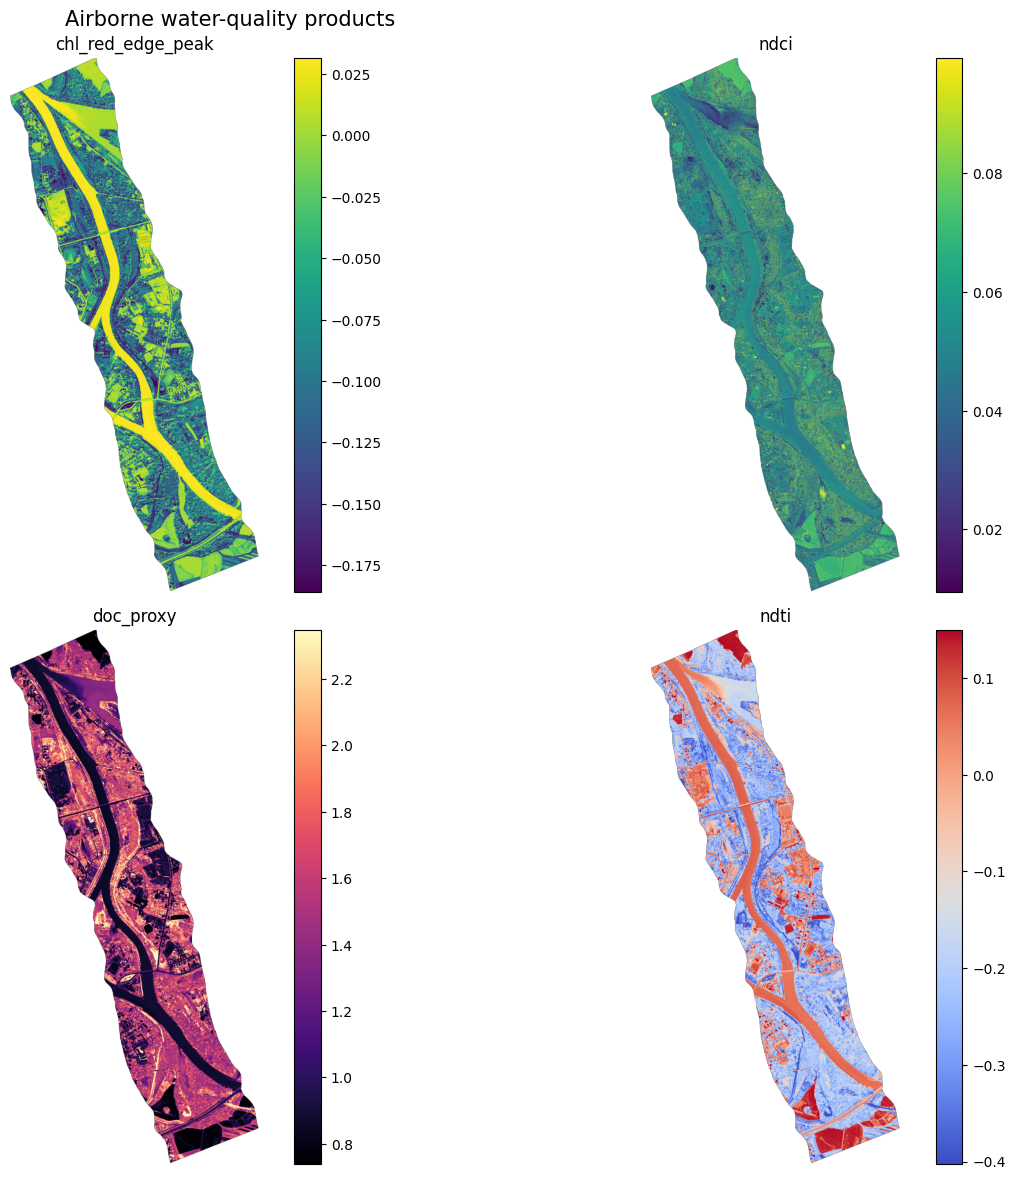

,index,valid_pixels,mean,std,p05,median,p95
0,chl_red_edge_peak,3174220,-0.063779,0.066540,-0.168553,-0.064473,0.029273
1,ndci,3174220,0.053557,0.024207,0.019653,0.053528,0.087221
2,doc_proxy,3174220,1.386396,0.446843,0.780269,1.414966,2.140762
3,ndti,3174220,-0.131950,0.163333,-0.363212,-0.171831,0.123426


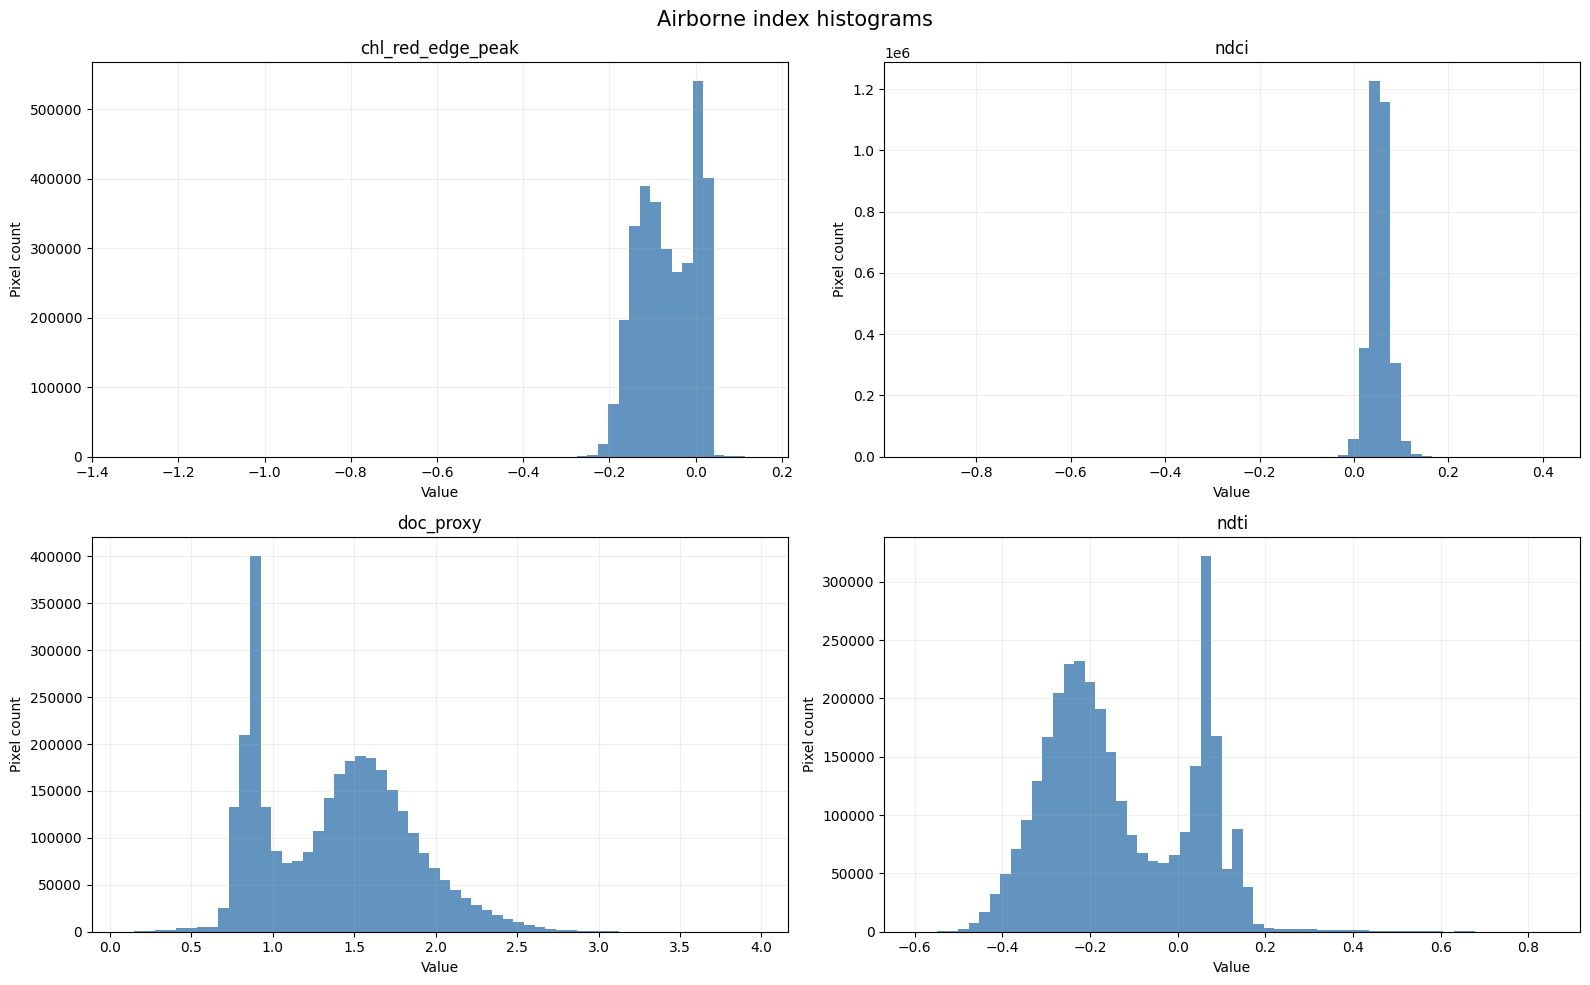

In [12]:
r560 = band_by_wavelength(img, wavelengths, 560, invalid_mask=invalid_mask, ignore_value=ignore_value)
r665 = band_by_wavelength(img, wavelengths, 665, invalid_mask=invalid_mask, ignore_value=ignore_value)
r705 = band_by_wavelength(img, wavelengths, 705, invalid_mask=invalid_mask, ignore_value=ignore_value)
r740 = band_by_wavelength(img, wavelengths, 740, invalid_mask=invalid_mask, ignore_value=ignore_value)

index_maps = {
    "chl_red_edge_peak": chlorophyll_red_edge_peak(r665, r705, r740),
    "ndci": ndci(r665, r705),
    "doc_proxy": doc_proxy_green_red(r560, r665),
    "ndti": ndti(r560, r665),
}

display_cmaps = {
    "chl_red_edge_peak": "viridis",
    "ndci": "viridis",
    "doc_proxy": "magma",
    "ndti": "coolwarm",
}

def finite_limits(array: np.ndarray) -> tuple[float, float]:
    values = array[np.isfinite(array)]
    if values.size == 0:
        return -1.0, 1.0
    lo, hi = np.percentile(values, [2, 98])
    if lo == hi:
        return float(lo - 1e-6), float(hi + 1e-6)
    return float(lo), float(hi)

fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={"aspect": "auto"})
fig.suptitle("Airborne water-quality products", fontsize=15)

for ax, (name, array) in zip(axes.flat, index_maps.items(), strict=True):
    lo, hi = finite_limits(array)
    image = ax.imshow(array, cmap=display_cmaps[name], vmin=lo, vmax=hi)
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

stats_rows = []
for name, array in index_maps.items():
    values = array[np.isfinite(array)]
    stats_rows.append(
        {
            "index": name,
            "valid_pixels": int(values.size),
            "mean": float(np.mean(values)) if values.size else np.nan,
            "std": float(np.std(values)) if values.size else np.nan,
            "p05": float(np.percentile(values, 5)) if values.size else np.nan,
            "median": float(np.percentile(values, 50)) if values.size else np.nan,
            "p95": float(np.percentile(values, 95)) if values.size else np.nan,
        }
    )

index_stats = pd.DataFrame(stats_rows)
display(index_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Airborne index histograms", fontsize=15)

for ax, (name, array) in zip(axes.flat, index_maps.items(), strict=True):
    values = array[np.isfinite(array)]
    ax.hist(values, bins=60, color="steelblue", alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel("Value")
    ax.set_ylabel("Pixel count")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## Sentinel-2 Search And Selection

This section prepares the satellite phase by converting the airborne ENVI footprint
to WGS84, searching the Planetary Computer STAC catalog near `2025-06-17`, ranking
candidate Sentinel-2 scenes, and selecting the best item.


In [13]:
target_grid = scene_grid_from_envi(meta)
scene_bbox_wgs84 = scene_bbox_wgs84_from_envi(meta)
scene_bbox_wgs84

try:
    catalog = open_catalog()
    s2_items = search_s2_items(
        scene_bbox_wgs84,
        TARGET_DATE,
        day_window=S2_DAY_WINDOW,
        cloud_limit=S2_CLOUD_LIMIT,
        catalog=catalog,
    )
    s2_candidates = pd.DataFrame([describe_item(item, TARGET_DATE) for item in s2_items])
    s2_item = select_best_item(s2_items, TARGET_DATE)
    display(s2_candidates)
    print(f"Selected Sentinel-2 item: {s2_item.id}")
except Exception as exc:
    s2_items = []
    s2_candidates = pd.DataFrame()
    s2_item = None
    print(f"Live Sentinel-2 search unavailable in this environment: {exc}")


,id,datetime,days_from_target,eo_cloud_cover,platform,mgrs_tile
0,S2C_MSIL2A_20250615T095051_R079_T33UYR_2025061...,2025-06-15T09:50:51.025000+00:00,2,0.461973,Sentinel-2C,33UYR
1,S2B_MSIL2A_20250613T100029_R122_T33UYR_2025061...,2025-06-13T10:00:29.025000+00:00,4,1.484568,Sentinel-2B,33UYR


Selected Sentinel-2 item: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401


## Sentinel-2 Band Download And Local Cache

If the live STAC search succeeds, this cell downloads and reprojects the required
Sentinel-2 bands to the airborne scene grid and records the local cache paths. If
the environment is offline, the cell exits cleanly without failing the notebook.


In [14]:
if s2_item is None:
    print("Skipping Sentinel-2 download because no live item is available.")
    s2_band_files = {}
    s2_stack = {}
else:
    SENTINEL2_DIR.mkdir(parents=True, exist_ok=True)
    s2_band_files = {
        band_name: download_band(s2_item, band_name, SENTINEL2_DIR, target_grid)
        for band_name in SENTINEL2_REQUIRED_BANDS
    }
    s2_stack = load_local_stack(s2_band_files)
    download_table = pd.DataFrame(
        [
            {
                "band": band_name,
                "path": str(path),
                "shape": tuple(s2_stack[band_name].shape),
            }
            for band_name, path in s2_band_files.items()
        ]
    )
    display(download_table)


,band,path,shape
0,B03,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
1,B04,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
2,B05,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
3,B06,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
4,B08,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
5,B11,/Users/ernest.molczan/PycharmProjects/eolabs-c...,"(4300, 2001)"
